In [1]:
# https://www.bioconductor.org/packages/release/bioc/vignettes/GSVA/inst/doc/GSVA.html

In [2]:
# The GSVA package provides the implementation of four single-sample gene set enrichment methods, 
# concretely zscore, plage, ssGSEA and its own called GSVA

In [3]:
library(GSVA)

In [4]:
cat("

Gene set variation analysis (GSVA) provides an estimate of pathway activity by transforming an input gene-by-sample expression data matrix 
into a corresponding gene-set-by-sample expression data matrix. 

This resulting expression data matrix can be then used with classical analytical methods such as differential expression, classification, 
survival analysis, clustering or correlation analysis in a pathway-centric manner. 

One can also perform sample-wise comparisons between pathways and other molecular data types such as microRNA expression or binding data, 
copy-number variation (CNV) data or single nucleotide polymorphisms (SNPs).

")



Gene set variation analysis (GSVA) provides an estimate of pathway activity by transforming an input gene-by-sample expression data matrix 
into a corresponding gene-set-by-sample expression data matrix. 

This resulting expression data matrix can be then used with classical analytical methods such as differential expression, classification, 
survival analysis, clustering or correlation analysis in a pathway-centric manner. 

One can also perform sample-wise comparisons between pathways and other molecular data types such as microRNA expression or binding data, 
copy-number variation (CNV) data or single nucleotide polymorphisms (SNPs).



In [5]:
# gsva()

# two input arguments:

# a normalized gene expression dataset
# a collection of gene sets

# kcdf: The first step of the GSVA algorithm brings gene expression profiles to a common scale by calculating 
# an expression statistic through the estimation of the CDF across samples. 

# maxDiff: The last step of the GSVA algorithm calculates the gene set enrichment score from 
# two Kolmogorov-Smirnov random walk statistics

In [6]:
library(org.Hs.eg.db)

# goannot <- select(org.Hs.eg.db, keys=keys(org.Hs.eg.db), columns="GO")
# head(goannot)

library(GSEABase)
library(GSVAdata)

data(c2BroadSets)
class(c2BroadSets)
c2BroadSets

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view w

[1] "GeneSetCollection"
attr(,"package")
[1] "GSEABase"

GeneSetCollection
  names: NAKAMURA_CANCER_MICROENVIRONMENT_UP, NAKAMURA_CANCER_MICROENVIRONMENT_DN, ..., ST_PHOSPHOINOSITIDE_3_KINASE_PATHWAY (3272 total)
  unique identifiers: 5167, 100288400, ..., 57191 (29340 total)
  types in collection:
    geneIdType: EntrezIdentifier (1 total)
    collectionType: BroadCollection (1 total)

In [7]:
names(c2BroadSets)

[1] "NAKAMURA_CANCER_MICROENVIRONMENT_UP"                                                                      
   [2] "NAKAMURA_CANCER_MICROENVIRONMENT_DN"                                                                      
   [3] "WEST_ADRENOCORTICAL_TUMOR_MARKERS_UP"                                                                     
   [4] "WEST_ADRENOCORTICAL_TUMOR_MARKERS_DN"                                                                     
   [5] "WINTER_HYPOXIA_UP"                                                                                        
   [6] "WINTER_HYPOXIA_DN"                                                                                        
   [7] "PARENT_MTOR_SIGNALING_UP"                                                                                 
   [8] "PARENT_MTOR_SIGNALING_DN"                                                                                 
   [9] "PYEON_HPV_POSITIVE_TUMORS_UP"                                                                             
  [10] "PYEON_HPV_POSITIVE_TUMORS_DN"                                                                             
  [11] "NAKAMURA_TUMOR_ZONE_PERIPHERAL_VS_CENTRAL_UP"                                                             
  [12] "NAKAMURA_TUMOR_ZONE_PERIPHERAL_VS_CENTRAL_DN"                                                             
  [13] "PICCALUGA_ANGIOIMMUNOBLASTIC_LYMPHOMA_UP"                                                                 
  [14] "PICCALUGA_ANGIOIMMUNOBLASTIC_LYMPHOMA_DN"                                                                 
  [15] "LU_TUMOR_VASCULATURE_UP"                                                                                  
  [16] "LU_TUMOR_VASCULATURE_DN"                                                                                  
  [17] "KORKOLA_EMBRYONAL_CARCINOMA_UP"                                                                           
  [18] "KORKOLA_EMBRYONAL_CARCINOMA_DN"                                                                           
  [19] "KORKOLA_TERATOMA_UP"                                                                                      
  [20] "KORKOLA_TERATOMA_DN"                                                                                      
  [21] "KORKOLA_YOLK_SAC_TUMOR_UP"                                                                                
  [22] "KORKOLA_YOLK_SAC_TUMOR_DN"                                                                                
  [23] "KORKOLA_CHORIOCARCINOMA_UP"                                                                               
  [24] "KORKOLA_CHORIOCARCINOMA_DN"                                                                               
  [25] "KORKOLA_SEMINOMA_UP"                                                                                      
  [26] "KORKOLA_SEMINOMA_DN"                                                                                      
  [27] "WATANABE_RECTAL_CANCER_RADIOTHERAPY_RESPONSIVE_UP"                                                        
  [28] "WATANABE_RECTAL_CANCER_RADIOTHERAPY_RESPONSIVE_DN"                                                        
  [29] "HOLLMAN_APOPTOSIS_VIA_CD40_UP"                                                                            
  [30] "HOLLMAN_APOPTOSIS_VIA_CD40_DN"                                                                            
  [31] "LIU_PROSTATE_CANCER_UP"                                                                                   
  [32] "LIU_PROSTATE_CANCER_DN"                                                                                   
  [33] "LIU_SOX4_TARGETS_UP"                                                                                      
  [34] "LIU_SOX4_TARGETS_DN"                                                                                      
  [35] "ONKEN_UVEAL_MELANOMA_UP"                                                             

In [8]:
length(c2BroadSets)

[1] 3272

In [9]:
library(GSEABase)
library(GSVA)

URL <- "https://data.broadinstitute.org/gsea-msigdb/msigdb/release/2024.1.Hs/c7.immunesigdb.v2024.1.Hs.symbols.gmt"
c7.genesets <- readGMT(URL)

In [10]:
c7.genesets 

GeneSetCollection
  names: GOLDRATH_EFF_VS_MEMORY_CD8_TCELL_DN, GOLDRATH_EFF_VS_MEMORY_CD8_TCELL_UP, ..., KAECH_NAIVE_VS_MEMORY_CD8_TCELL_UP (4872 total)
  unique identifiers: ABCA2, ABCC5, ..., LINC00841 (20457 total)
  types in collection:
    geneIdType: SymbolIdentifier (1 total)
    collectionType: NullCollection (1 total)

In [11]:
gsvaAnnotation(c7.genesets) <- SymbolIdentifier("org.Hs.eg.db")

In [12]:
c7.genesets 

GeneSetCollection
  names: GOLDRATH_EFF_VS_MEMORY_CD8_TCELL_DN, GOLDRATH_EFF_VS_MEMORY_CD8_TCELL_UP, ..., KAECH_NAIVE_VS_MEMORY_CD8_TCELL_UP (4872 total)
  unique identifiers: ABCA2, ABCC5, ..., LINC00841 (20457 total)
  types in collection:
    geneIdType: SymbolIdentifier (1 total)
    collectionType: NullCollection (1 total)

In [13]:
cat("Quantification of pathway activity in bulk microarray and RNA-seq data")

Quantification of pathway activity in bulk microarray and RNA-seq data

In [14]:
# gene expression data of lymphoblastoid cell lines (LCL) from HapMap individuals

In [15]:
library(Biobase)

data(commonPickrellHuang)

stopifnot(identical(featureNames(huangArrayRMAnoBatchCommon_eset),
                    featureNames(pickrellCountsArgonneCQNcommon_eset)))
stopifnot(identical(sampleNames(huangArrayRMAnoBatchCommon_eset),
                    sampleNames(pickrellCountsArgonneCQNcommon_eset)))

In [16]:
canonicalC2BroadSets <- c2BroadSets[c(grep("^KEGG", names(c2BroadSets)),
                                      grep("^REACTOME", names(c2BroadSets)),
                                      grep("^BIOCARTA", names(c2BroadSets)))]
canonicalC2BroadSets

GeneSetCollection
  names: KEGG_GLYCOLYSIS_GLUCONEOGENESIS, KEGG_CITRATE_CYCLE_TCA_CYCLE, ..., BIOCARTA_ACTINY_PATHWAY (833 total)
  unique identifiers: 55902, 2645, ..., 8544 (6744 total)
  types in collection:
    geneIdType: EntrezIdentifier (1 total)
    collectionType: BroadCollection (1 total)

In [17]:
names(canonicalC2BroadSets)

[1] "KEGG_GLYCOLYSIS_GLUCONEOGENESIS"                                                                          
  [2] "KEGG_CITRATE_CYCLE_TCA_CYCLE"                                                                             
  [3] "KEGG_PENTOSE_PHOSPHATE_PATHWAY"                                                                           
  [4] "KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS"                                                            
  [5] "KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM"                                                                     
  [6] "KEGG_GALACTOSE_METABOLISM"                                                                                
  [7] "KEGG_ASCORBATE_AND_ALDARATE_METABOLISM"                                                                   
  [8] "KEGG_FATTY_ACID_METABOLISM"                                                                               
  [9] "KEGG_STEROID_BIOSYNTHESIS"                                                                                
 [10] "KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS"                                                                      
 [11] "KEGG_STEROID_HORMONE_BIOSYNTHESIS"                                                                        
 [12] "KEGG_OXIDATIVE_PHOSPHORYLATION"                                                                           
 [13] "KEGG_PURINE_METABOLISM"                                                                                   
 [14] "KEGG_PYRIMIDINE_METABOLISM"                                                                               
 [15] "KEGG_ALANINE_ASPARTATE_AND_GLUTAMATE_METABOLISM"                                                          
 [16] "KEGG_GLYCINE_SERINE_AND_THREONINE_METABOLISM"                                                             
 [17] "KEGG_CYSTEINE_AND_METHIONINE_METABOLISM"                                                                  
 [18] "KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_DEGRADATION"                                                           
 [19] "KEGG_VALINE_LEUCINE_AND_ISOLEUCINE_BIOSYNTHESIS"                                                          
 [20] "KEGG_LYSINE_DEGRADATION"                                                                                  
 [21] "KEGG_ARGININE_AND_PROLINE_METABOLISM"                                                                     
 [22] "KEGG_HISTIDINE_METABOLISM"                                                                                
 [23] "KEGG_TYROSINE_METABOLISM"                                                                                 
 [24] "KEGG_PHENYLALANINE_METABOLISM"                                                                            
 [25] "KEGG_TRYPTOPHAN_METABOLISM"                                                                               
 [26] "KEGG_BETA_ALANINE_METABOLISM"                                                                             
 [27] "KEGG_TAURINE_AND_HYPOTAURINE_METABOLISM"                                                                  
 [28] "KEGG_SELENOAMINO_ACID_METABOLISM"                                                                         
 [29] "KEGG_GLUTATHIONE_METABOLISM"                                                                              
 [30] "KEGG_STARCH_AND_SUCROSE_METABOLISM"                                                                       
 [31] "KEGG_N_GLYCAN_BIOSYNTHESIS"                                                                               
 [32] "KEGG_OTHER_GLYCAN_DEGRADATION"                                                                            
 [33] "KEGG_O_GLYCAN_BIOSYNTHESIS"                                                                               
 [34] "KEGG_AMINO_SUGAR_AND_NUCLEOTIDE_SUGAR_METABOLISM"                                                         
 [35] "KEGG_GLYCOSAMINOGLYCAN_DEGRADATION"                                                                       
 [36] "KEGG_

In [18]:
gs.list <- geneIds(c2BroadSets)

str(gs.list)

List of 3272
 $ NAKAMURA_CANCER_MICROENVIRONMENT_UP                                                                      : chr [1:26] "5167" "100288400" "338328" "388" ...
 $ NAKAMURA_CANCER_MICROENVIRONMENT_DN                                                                      : chr [1:46] "55215" "9319" "81610" "9455" ...
 $ WEST_ADRENOCORTICAL_TUMOR_MARKERS_UP                                                                     : chr [1:21] "5142" "6781" "580" "6713" ...
 $ WEST_ADRENOCORTICAL_TUMOR_MARKERS_DN                                                                     : chr [1:20] "125" "2619" "5919" "4856" ...
 $ WINTER_HYPOXIA_UP                                                                                        : chr [1:91] "7022" "404550" "5738" "9456" ...
 $ WINTER_HYPOXIA_DN                                                                                        : chr [1:50] "5168" "9452" "3112" "91526" ...
 $ PARENT_MTOR_SIGNALING_UP                                 

In [19]:
huangPar <- gsvaParam(huangArrayRMAnoBatchCommon_eset, canonicalC2BroadSets,
                      minSize=5, maxSize=500)
esmicro <- gsva(huangPar)
esmicro

ℹ GSVA version 2.4.9

ℹ Searching for rows with constant values

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating row ECDFs

ℹ Calculating column ranks

ℹ Mapping identifiers

ℹ GSVA dense (classical) algorithm

ℹ Calculating GSVA scores

✔ Calculations finished



ExpressionSet (storageMode: lockedEnvironment)
assayData: 804 features, 36 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: NA19099 NA18523 ... NA19171 (36 total)
  varLabels: CoriellCellLineID Population ... Batch (7 total)
  varMetadata: channel labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

In [20]:
# esmicro is an ExpressionSet, not a SummarizedExperiment.

library(Biobase)
score.mat <- exprs(esmicro)

class(score.mat)
dim(score.mat)

score.mat[1:10, 1:10]

[1] "matrix" "array"

[1] 804  36

,NA19099,NA18523,NA19144,NA19137,NA18861,NA19116,NA19130,NA19131,NA19119,NA19152
KEGG_GLYCOLYSIS_GLUCONEOGENESIS,-0.14230367,-0.3154226,-0.39125278,0.21314789,0.3982731,-0.02979645,0.17463104,0.26708537,0.19741315,0.07317030
KEGG_CITRATE_CYCLE_TCA_CYCLE,-0.20050240,0.2516592,0.01290791,-0.23516857,0.1673898,-0.18868132,-0.09560810,0.02332307,0.25320461,-0.29805871
KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.13532736,-0.3454335,0.01171014,0.10461510,0.5338337,0.08497909,-0.07344553,0.33973602,0.18529099,-0.01914787
KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,-0.04674354,0.2631958,-0.24777062,-0.57095581,-0.1515618,-0.12045011,-0.22560104,0.15410774,0.17142276,-0.41538904
KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,-0.05032619,-0.2581911,-0.27263716,0.02525198,0.4651490,-0.07264436,-0.08922090,0.17977844,0.17645488,0.08577523
KEGG_GALACTOSE_METABOLISM,-0.50995845,-0.3290795,-0.33917558,0.17973234,0.5893476,-0.05162470,-0.02715106,0.01129468,0.11401380,0.20364017
KEGG_ASCORBATE_AND_ALDARATE_METABOLISM,0.39703075,0.1027168,-0.05575844,0.31975221,0.1178644,-0.47757507,-0.27421719,0.48963944,-0.09204445,-0.05615840
KEGG_FATTY_ACID_METABOLISM,0.03499557,0.1834816,0.20986894,-0.24526403,0.2087407,-0.11867729,-0.23905993,0.49914991,0.38962162,-0.20723774
KEGG_STEROID_BIOSYNTHESIS,0.20009807,-0.1815906,-0.49505787,-0.25999420,0.1903187,-0.32380418,0.40236927,0.55554536,0.33588386,-0.30628334
KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS,-0.22614949,0.3278955,-0.04496340,0.34520160,-0.3240801,-0.37005067,0.38061477,0.50600366,-0.27763360,-0.46620361


In [21]:
esmicro[1:5, 1:5]

ExpressionSet (storageMode: lockedEnvironment)
assayData: 5 features, 5 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: NA19099 NA18523 ... NA18861 (5 total)
  varLabels: CoriellCellLineID Population ... Batch (7 total)
  varMetadata: channel labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

In [22]:
pickrellPar <- gsvaParam(pickrellCountsArgonneCQNcommon_eset,
                         canonicalC2BroadSets, minSize=5, maxSize=500,
                         kcdf="Poisson")
esrnaseq <- gsva(pickrellPar)
esrnaseq 

ℹ GSVA version 2.4.9

ℹ Searching for rows with constant values

ℹ Calculating GSVA ranks

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Poisson kernels

ℹ Calculating row ECDFs

Estimating ECDFs ■■■■■■■■■■                        31% |  ETA:  2s
Estimating ECDFs ■■■■■■■■■■■■                      37% |  ETA:  2s
Estimating ECDFs ■■■■■■■■■■■■■                     41% |  ETA:  2s
Estimating ECDFs ■■■■■■■■■■■■■■■                   47% |  ETA:  2s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■                57% |  ETA:  2s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■              63% |  ETA:  1s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■             68% |  ETA:  1s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■■■           73% |  ETA:  1s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■■■■■         80% |  ETA:  1s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■■■■■■        84% |  ETA:  1s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■■■■■■■■      89% |  ETA:  0s
Estimating ECDFs ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■     93% |  ETA:

ExpressionSet (storageMode: lockedEnvironment)
assayData: 804 features, 36 samples 
  element names: exprs 
protocolData: none
phenoData
  sampleNames: NA19099 NA18523 ... NA19171 (36 total)
  varLabels: CoriellCellLineID Population ... FamilyRelationship (5
    total)
  varMetadata: channel labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

In [23]:
library(Biobase)

score.mat <- exprs(esrnaseq)

class(score.mat)

dim(score.mat)

score.mat[1:10, 1:10]

head(rownames(score.mat))   # pathway names
head(colnames(score.mat))   # sample names

[1] "matrix" "array"

[1] 804  36

,NA19099,NA18523,NA19144,NA19137,NA18861,NA19116,NA19130,NA19131,NA19119,NA19152
KEGG_GLYCOLYSIS_GLUCONEOGENESIS,0.22812891,-0.26335522,-0.3747005,0.29073233,0.17079093,-0.45765232,0.5001260,-0.09532256,-0.47875336,0.2005760985
KEGG_CITRATE_CYCLE_TCA_CYCLE,0.19353985,-0.20067180,-0.3193682,0.25730022,0.09459388,-0.14437972,0.5803708,0.22069982,-0.48416294,-0.0911133032
KEGG_PENTOSE_PHOSPHATE_PATHWAY,0.39550501,-0.35132141,-0.1411042,0.35824306,0.16435766,-0.26645789,0.6676382,0.18030231,-0.55044204,0.0557952309
KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS,0.30352162,-0.23381641,-0.2716007,-0.24624721,-0.06071677,0.04536230,0.3882295,-0.15951208,0.02167093,-0.0009868643
KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM,0.11033580,-0.06220681,-0.0458456,0.44259632,-0.43860752,-0.26354440,0.4735264,0.10394622,-0.35492025,0.1683707621
KEGG_GALACTOSE_METABOLISM,0.05968213,-0.42388064,-0.0400420,0.34947724,-0.12227027,-0.46339930,0.5169587,-0.01678146,-0.35296517,0.2445369055
KEGG_ASCORBATE_AND_ALDARATE_METABOLISM,0.51787543,0.04203491,-0.1245109,-0.03806419,0.31987038,-0.46521958,0.3970870,0.01144431,0.37686424,0.5270750790
KEGG_FATTY_ACID_METABOLISM,0.20823397,-0.24192108,-0.3037948,0.18701421,0.29338100,-0.08777247,0.5226777,0.27472038,-0.34093551,0.1468463154
KEGG_STEROID_BIOSYNTHESIS,0.33555025,0.08044720,-0.5265414,-0.26423348,0.32230491,0.07428098,0.3004237,0.29034851,-0.28507907,-0.6240119550
KEGG_PRIMARY_BILE_ACID_BIOSYNTHESIS,0.15631681,0.08478196,-0.5293243,0.55299056,0.26301727,-0.59722302,0.1219205,0.47568307,0.39619228,-0.4647553926


[1] "KEGG_GLYCOLYSIS_GLUCONEOGENESIS"              
[2] "KEGG_CITRATE_CYCLE_TCA_CYCLE"                 
[3] "KEGG_PENTOSE_PHOSPHATE_PATHWAY"               
[4] "KEGG_PENTOSE_AND_GLUCURONATE_INTERCONVERSIONS"
[5] "KEGG_FRUCTOSE_AND_MANNOSE_METABOLISM"         
[6] "KEGG_GALACTOSE_METABOLISM"

[1] "NA19099" "NA18523" "NA19144" "NA19137" "NA18861" "NA19116"

In [24]:
cat("Molecular signature identification")

Molecular signature identification

In [25]:
grep("brain|Tx|Db", ls(), value = TRUE, ignore.case = TRUE)

character(0)

In [26]:
data(brainTxDbSets)

In [27]:
brainTxDbSets

$astrocytic_up
 [1] "GRHL1"     "GPAM"      "PAPSS2"    "MERTK"     "BTG1"      "SLC46A1"  
 [7] "SPIRE1"    "LYRM4"     "HEPH"      "CHRDL1"    "ADORA2B"   "ELOVL2"   
[13] "FGFR3"     "TMEM51"    "CYP7B1"    "PHKG1"     "DNAI1"     "MFGE8"    
[19] "PTPLAD1"   "GABRG1"    "TECTB"     "AQP9"      "CKAP5"     "STK38L"   
[25] "SLC1A2"    "KCNJ16"    "ABCB9"     "HEY2"      "LGI4"      "SCG3"     
[31] "VNN1"      "RGS20"     "TTYH3"     "SLC30A10"  "VEGFA"     "CBS"      
[37] "HSD11B1"   "ADCYAP1R1" "FGD6"      "ELF5"      "RNF24"     "IL17RD"   
[43] "NMB"       "IMPA2"     "NRARP"     "GRIN2C"    "RASA2"     "RARRES1"  
[49] "NTSR2"     "TTPA"      "PPP1R3D"   "PLD2"      "RSPO1"     "SLC27A1"  
[55] "PANK1"     "PLA2G3"    "PPARA"     "COX10"     "AGT"       "SLC13A5"  
[61] "SYPL2"     "RORB"      "ABHD1"     "SLC7A11"   "AKT2"      "KCTD14"   
[67] "AIFM3"     "SLC6A11"   "GLT25D2"   "BTBD17"    "HAPLN1"    "SLC7A10"  
[73] "CYP4F11"   "BMPR1B"    "KIAA1161"  "FARS2"     "TNFRSF19"  "ABCD2"    
[79] "THRSP"     "FAM20A"    "SLC25A34"  "MYOM3"     "ATP13A4"   "EGFL6"    
[85] "DIO2"     

$astroglia_up
 [1] "BST2"      "SERPING1"  "ACTA2"     "C9orf167"  "C1orf31"   "ANXA4"    
 [7] "ATOH8"     "PSRC1"     "C2orf40"   "PTRH1"     "COL4A6"    "FOXJ1"    
[13] "MSN"       "COL5A1"    "PRSS23"    "PON3"      "CP"        "MXRA8"    
[19] "TRAF1"     "LOXL2"     "CTTN"      "CCNG1"     "NPVF"      "MRPS6"    
[25] "AEBP1"     "TMEM37"    "TNFRSF12A" "EMP3"      "LRP2"      "C1QTNF1"  
[31] "TSPO"      "IGFBP3"    "CCDC96"    "PSTPIP1"   "TAGLN"     "NOX4"     
[37] "SPATA6"    "FAM26E"    "TBC1D2B"   "GPNMB"     "EREG"      "COL8A1"   
[43] "DYSF"      "UGT1A1"    "LBP"       "KAZALD1"   "CAPS2"     "LGALS3"   
[49] "ITGBL1"    "SEMA3B"    "TIMP1"     "FAS"       "SERPINE1"  "MORC4"    
[55] "LOX"       "CASP1"     "WISP2"     "GLIPR2"    "LPIN3"     "C11orf88" 
[61] "FMOD"      "KLHL21"    "GNA14"     "P2RY1"     "RHOD"      "CRYGS"    
[67] "HMOX1"     "PKP2"      "FAM178A"   "LTBP2"     "AKR1B10"   "INSL6"    
[73] "FBLN5"     "FER1L3"    "CNN1"      "OMD"       "GPR126"    "OGN"      
[79] "ANXA1"     "PQLC3"     "DEFB1"     "RASSF4"    "CASP12"    "NUAK2"    
[85] "SUCNR1"    "CD109"     "LCN2"      "C3"       

$neuronal_up
 [1] "STXBP1"    "JPH4"      "CACNG3"    "BRUNOL6"   "CLSTN2"    "FAM123C"  
 [7] "PPFIA2"    "NRGN"      "MAL2"      "PRDM8"     "C6orf142"  "FABP3"    
[13] "GRP"       "NEFM"      "PRSS12"    "CRHBP"     "FGF9"      "CALN1"    
[19] "SLC25A22"  "PNOC"      "GAD2"      "GPR22"     "ENO2"      "SH2D5"    
[25] "NSF"       "C20orf103" "CNTNAP4"   "MYH3"      "RTN4RL1"   "KRT222P"  
[31] "CBLN4"     "SLC35F4"   "SYT4"      "TSPYL5"    "CKMT1A"    "SYT1"     
[37] "SLC6A17"   "SATB2"     "BCL11B"    "NEFL"      "RASGEF1A"  "SYT5"     
[43] "NXPH2"     "SV2B"      "SCG2"      "KIAA1239"  "MYT1L"     "EPHA7"    
[49] "COL19A1"   "ITPKA"     "CPNE4"     "GABRG2"    "GABRD"     "CAMK2B"   
[55] "BCL11A"    "KCNIP4"    "DRD1"      "RPRML"     "NTS"       "TRHDE"    
[61] "MEF2C"     "SYT13"     "HPCA"      "PENK"      "STX1A"     "MYO5B"    
[67] "CRH"       "SLC6A7"    "CPNE5"     "PGM2L1"    "GREM2"     "SLC8A1"   
[73] "KIAA1045"  "SLC17A6"   "BRUNOL4"   "SIDT1"     "ICAM5"     "CDH9"     
[79] "LIN7B"     "SST"       "CCK"       "NELL1"     "EPB49"     "HCN1"     
[85] "RASL10A"   "RAMP3"     "GABRA5"    "NAPB"      "KIAA0319"  "RGS4"     
[91] "DYNC1I1"   "CAMKV"     "GDA"       "TBR1"      "GLRA2"     "HS3ST2"   
[97] "CALB1"     "NEUROD6"  

$oligodendrocytic_up
 [1] "DCT"      "ZNF536"   "GNG8"     "ELOVL6"   "NR2C1"    "RCBTB1"  
 [7] "NRM"      "RNASEH2B" "PUS7"     "DOCK10"   "AGAP11"   "CPOX"    
[13] "POP4"     "BACE1"    "KIAA0415" "FBP1"     "WIPF1"    "TSPAN2"  
[19] "DCPS"     "RBM11"    "MAP6D1"   "SIRT2"    "SOX8"     "SLC35B2" 
[25] "USP16"    "KIAA1333" "EVI2A"    "KLRAQ1"   "EPN2"     "CLN8"    
[31] "FAM57A"   "C20orf57" "RNF122"   "DUSP19"   "FAM89A"   "C11orf9" 
[37] "LCORL"    "GAB3

In [28]:
# In (Verhaak et al. 2010) four subtypes of glioblastoma multiforme (GBM) -proneural, classical, neural and mesenchymal- 
# were identified by the characterization of distinct gene-level expression patterns. 

In [29]:
data(gbm_VerhaakEtAl)
gbm_eset

ExpressionSet (storageMode: lockedEnvironment)
assayData: 11861 features, 173 samples 
  element names: exprs 
protocolData: none
phenoData
  rowNames: TCGA.02.0003.01A.01 TCGA.02.0010.01A.01 ...
    TCGA.12.0620.01A.01 (173 total)
  varLabels: subtype
  varMetadata: labelDescription channel
featureData: none
experimentData: use 'experimentData(object)'
Annotation:  

In [30]:
gbmPar <- gsvaParam(gbm_eset, brainTxDbSets, maxDiff=FALSE)
gbm_es <- gsva(gbmPar)

ℹ GSVA version 2.4.9

ℹ Searching for rows with constant values

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating row ECDFs

ℹ Calculating column ranks

ℹ GSVA dense (classical) algorithm

ℹ Calculating GSVA scores

✔ Calculations finished



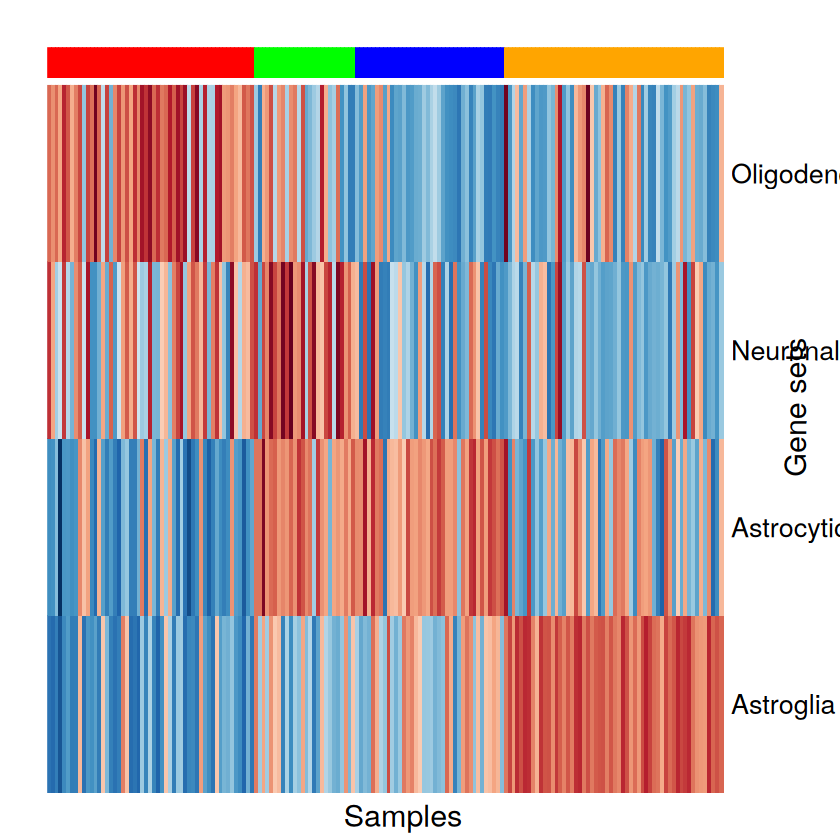

In [31]:
library(RColorBrewer)

subtypeOrder <- c("Proneural", "Neural", "Classical", "Mesenchymal")

sampleOrderBySubtype <- sort(match(gbm_es$subtype, subtypeOrder),
                             index.return=TRUE)$ix
subtypeXtable <- table(gbm_es$subtype)
subtypeColorLegend <- c(Proneural="red", Neural="green",
                        Classical="blue", Mesenchymal="orange")

geneSetOrder <- c("astroglia_up", "astrocytic_up", "neuronal_up",
                  "oligodendrocytic_up")

geneSetLabels <- gsub("_", " ", geneSetOrder)
hmcol <- colorRampPalette(brewer.pal(10, "RdBu"))(256)
hmcol <- hmcol[length(hmcol):1]

heatmap(exprs(gbm_es)[geneSetOrder, sampleOrderBySubtype], Rowv=NA,
        Colv=NA, scale="row", margins=c(3,5), col=hmcol,
        ColSideColors=rep(subtypeColorLegend[subtypeOrder],
                          times=subtypeXtable[subtypeOrder]),
        labCol="", gbm_es$subtype[sampleOrderBySubtype],
        labRow=paste(toupper(substring(geneSetLabels, 1,1)),
                     substring(geneSetLabels, 2), sep=""),
        cexRow=2, main=" \n ")
par(xpd=TRUE)

text(0.23,1.21, "Proneural", col="red", cex=1.2)
text(0.36,1.21, "Neural", col="green", cex=1.2)
text(0.47,1.21, "Classical", col="blue", cex=1.2)
text(0.62,1.21, "Mesenchymal", col="orange", cex=1.2)
mtext("Gene sets", side=4, line=0, cex=1.5)
mtext("Samples          ", side=1, line=4, cex=1.5)

In [32]:
cat("Differential expression at pathway level")

Differential expression at pathway level

In [33]:
data(geneprotExpCostaEtAl2021)
se <- geneExpCostaEtAl2021
se

class: SummarizedExperiment 
dim: 11279 21 
metadata(0):
assays(1): logCPM
rownames(11279): 100 10000 ... 9994 9997
rowData names(1): Symbol
colnames(21): BS03 BS04 ... BS23 BS24
colData names(2): FIR Sex

In [34]:
gsvaAnnotation(se) <- EntrezIdentifier("org.Hs.eg.db")

In [35]:
colData(se)

DataFrame with 21 rows and 2 columns
          FIR      Sex
     <factor> <factor>
BS03      yes   female
BS04      yes   female
BS05      yes   male  
BS06      no    female
BS07      no    female
...       ...      ...
BS20      no    female
BS21      yes   male  
BS22      no    male  
BS23      yes   male  
BS24      no    male  

In [36]:
table(colData(se))

     Sex
FIR   female male
  no       4    7
  yes      4    6

In [37]:
cat("Filtering of immunologic gene sets")

Filtering of immunologic gene sets

In [38]:
innatepat <- c("NKCELL_VS_.+_UP", "MAST_CELL_VS_.+_UP",
               "EOSINOPHIL_VS_.+_UP", "BASOPHIL_VS_.+_UP",
               "MACROPHAGE_VS_.+_UP", "NEUTROPHIL_VS_.+_UP")
innatepat <- paste(innatepat, collapse="|")
innategsets <- names(c7.genesets)[grep(innatepat, names(c7.genesets))]
length(innategsets)


adaptivepat <- c("CD4_TCELL_VS_.+_UP", "CD8_TCELL_VS_.+_UP", "BCELL_VS_.+_UP")
adaptivepat <- paste(adaptivepat, collapse="|")
adaptivegsets <- names(c7.genesets)[grep(adaptivepat, names(c7.genesets))]
excludepat <- c("NAIVE", "LUPUS", "MYELOID")
excludepat <- paste(excludepat, collapse="|")
adaptivegsets <- adaptivegsets[-grep(excludepat, adaptivegsets)]
length(adaptivegsets)


c7.genesets.filt <- c7.genesets[c(innategsets, adaptivegsets)]
length(c7.genesets.filt)


[1] 53

[1] 97

[1] 150

In [39]:
cat("Running GSVA")

Running GSVA

In [40]:
gsvapar <- gsvaParam(se, 
                     c7.genesets.filt, 
                     assay="logCPM", 
                     minSize=5,
                     maxSize=300)

In [41]:
es <- gsva(gsvapar)
es

ℹ GSVA version 2.4.9

ℹ Searching for rows with constant values

ℹ Calculating GSVA ranks

ℹ kcdf='auto' (default)

ℹ GSVA dense (classical) algorithm

ℹ Row-wise ECDF estimation with Gaussian kernels

ℹ Calculating row ECDFs

ℹ Calculating column ranks

ℹ Mapping identifiers

ℹ GSVA dense (classical) algorithm

ℹ Calculating GSVA scores

✔ Calculations finished



class: SummarizedExperiment 
dim: 150 21 
metadata(0):
assays(1): es
rownames(150):
  GSE18804_SPLEEN_MACROPHAGE_VS_BRAIN_TUMORAL_MACROPHAGE_UP
  GSE18804_SPLEEN_MACROPHAGE_VS_COLON_TUMORAL_MACROPHAGE_UP ...
  GSE7460_CD8_TCELL_VS_CD4_TCELL_ACT_UP
  GSE7460_CD8_TCELL_VS_TREG_ACT_UP
rowData names(1): gs
colnames(21): BS03 BS04 ... BS23 BS24
colData names(2): FIR Sex

In [42]:
assayNames(se)

[1] "logCPM"

In [43]:
assay(es)[1:3, 1:3]

,BS03,BS04,BS05
GSE18804_SPLEEN_MACROPHAGE_VS_BRAIN_TUMORAL_MACROPHAGE_UP,-0.06960698,0.05293804,-0.13353343
GSE18804_SPLEEN_MACROPHAGE_VS_COLON_TUMORAL_MACROPHAGE_UP,0.28080100,-0.13064317,-0.08696271
GSE18804_SPLEEN_MACROPHAGE_VS_TUMORAL_MACROPHAGE_UP,-0.12573692,0.16350068,-0.16517679


In [44]:
# head(lapply(geneSets(es), head))

head(geneSetSizes(es))

GSE18804_SPLEEN_MACROPHAGE_VS_BRAIN_TUMORAL_MACROPHAGE_UP 
                                                      122 
GSE18804_SPLEEN_MACROPHAGE_VS_COLON_TUMORAL_MACROPHAGE_UP 
                                                      141 
      GSE18804_SPLEEN_MACROPHAGE_VS_TUMORAL_MACROPHAGE_UP 
                                                      146 
                             GSE22886_NEUTROPHIL_VS_DC_UP 
                                                      105 
                       GSE22886_NEUTROPHIL_VS_MONOCYTE_UP 
                                                       82 
                     GSE2585_THYMIC_MACROPHAGE_VS_MTEC_UP 
                                                      142


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




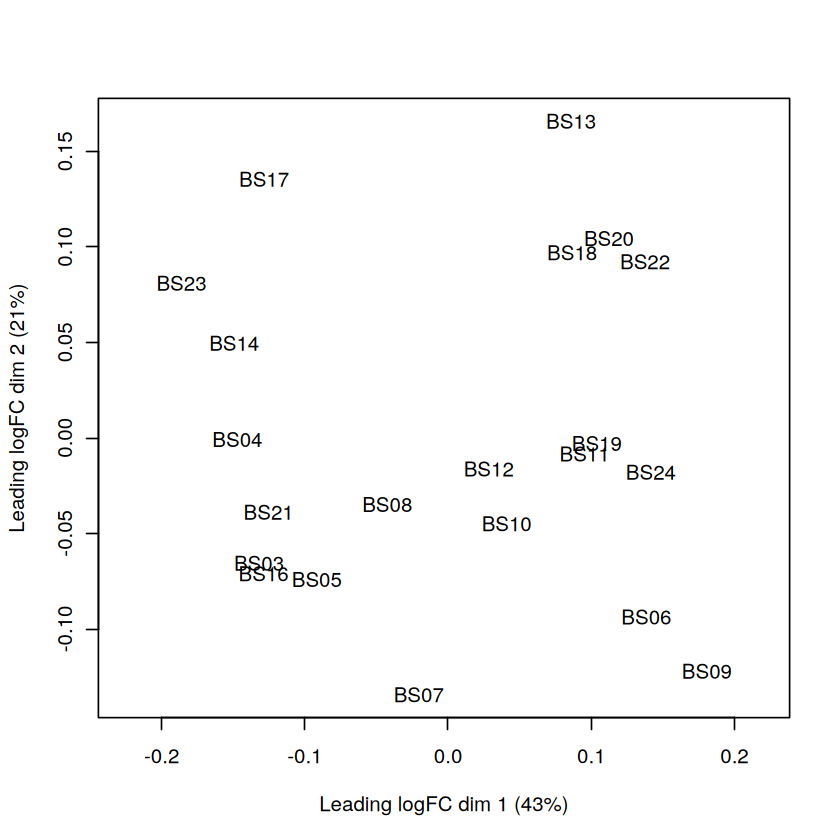

In [45]:
# MDS plot of GSVA enrichment scores.

library(limma)

plotMDS(assay(es))

In [46]:
es$FIR

[1] yes yes yes no  no  yes no  no  no  no  yes yes yes yes no  no  no  yes no 
[20] yes no 
Levels: no yes

In [47]:
cat("Differential expression")

Differential expression

In [48]:
library(sva)
library(limma)

## build design matrix of the model to which we fit the data
mod <- model.matrix(~ FIR, colData(es))
## build design matrix of the corresponding null model
mod0 <- model.matrix(~ 1, colData(es))
## estimate surrogate variables (SVs) with SVA
sv <- sva(assay(es), mod, mod0)

## add SVs to the design matrix of the model of interest
mod <- cbind(mod, sv$sv)
## fit linear models
fit <- lmFit(assay(es), mod)
## calculate moderated t-statistics using the robust regime
fit.eb <- eBayes(fit, robust=TRUE)
## summarize the extent of differential expression at 5% FDR
res <- decideTests(fit.eb)
summary(res)

Loading required package: mgcv

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:IRanges’:

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter


Attaching package: ‘genefilter’


The following objects are masked from ‘package:MatrixGenerics’:

    rowSds, rowVars


The following objects are masked from ‘package:matrixStats’:

    rowSds, rowVars


Loading required package: BiocParallel



Number of significant surrogate variables is:  4 
Iteration (out of 5 ):1  2  3  4  5  

       (Intercept) FIRyes                
Down            25     14  38  41  33  53
NotSig         119     97  65  78  70  94
Up               6     39  47  31  47   3

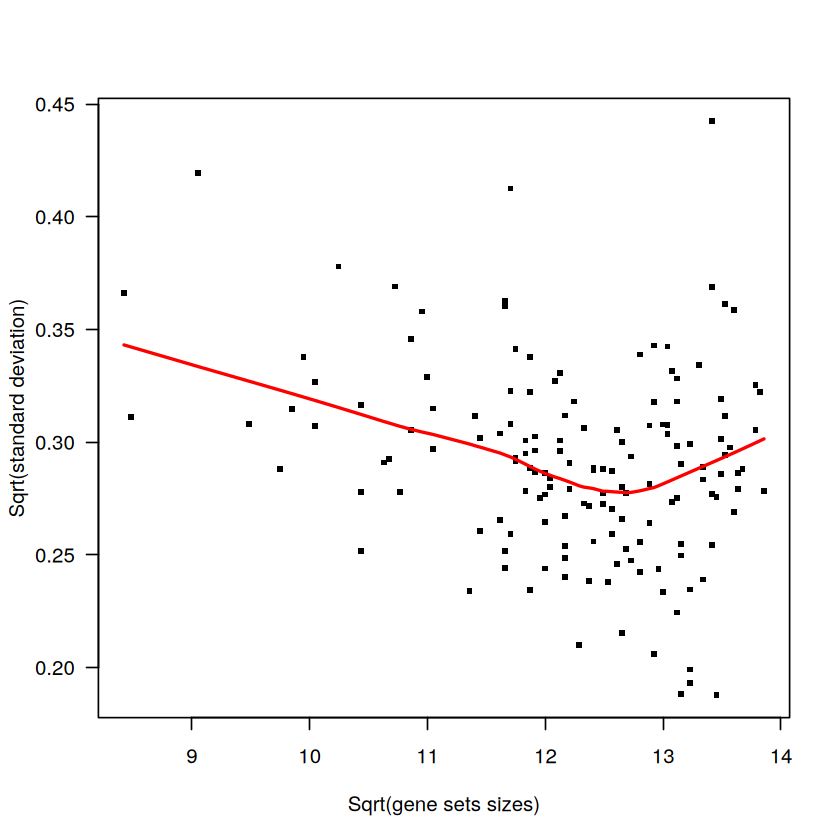

In [49]:
gssizes <- geneSetSizes(es)
plot(sqrt(gssizes), sqrt(fit.eb$sigma), xlab="Sqrt(gene sets sizes)",
          ylab="Sqrt(standard deviation)", las=1, pch=".", cex=4)
lines(lowess(sqrt(gssizes), sqrt(fit.eb$sigma)), col="red", lwd=2)

In [50]:
fit.eb.trend <- eBayes(fit, robust=TRUE, trend=sqrt(gssizes))
res <- decideTests(fit.eb.trend)
summary(res)

       (Intercept) FIRyes                
Down            28     15  37  41  33  58
NotSig         116     94  66  75  70  88
Up               6     41  47  34  47   4

In [51]:
tt <- topTable(fit.eb.trend, coef=2, n=Inf)
DEpwys <- rownames(tt)[tt$adj.P.Val <= 0.05]
DEpwys

[1] "GSE3039_CD4_TCELL_VS_ALPHABETA_CD8_TCELL_UP"                            
 [2] "GSE3982_NEUTROPHIL_VS_CENT_MEMORY_CD4_TCELL_UP"                         
 [3] "GSE3982_EOSINOPHIL_VS_CENT_MEMORY_CD4_TCELL_UP"                         
 [4] "GSE36392_EOSINOPHIL_VS_NEUTROPHIL_IL25_TREATED_LUNG_UP"                 
 [5] "GSE3982_NEUTROPHIL_VS_TH2_UP"                                           
 [6] "GSE22886_NEUTROPHIL_VS_DC_UP"                                           
 [7] "GSE3982_NEUTROPHIL_VS_NKCELL_UP"                                        
 [8] "GSE3982_EOSINOPHIL_VS_EFF_MEMORY_CD4_TCELL_UP"                          
 [9] "GSE3982_EOSINOPHIL_VS_NKCELL_UP"                                        
[10] "GSE3982_NEUTROPHIL_VS_EFF_MEMORY_CD4_TCELL_UP"                          
[11] "GSE3982_BASOPHIL_VS_CENT_MEMORY_CD4_TCELL_UP"                           
[12] "GSE3982_NEUTROPHIL_VS_TH1_UP"                                           
[13] "GSE3982_NEUTROPHIL_VS_BASOPHIL_UP"                                      
[14] "GSE3039_CD4_TCELL_VS_B2_BCELL_UP"                                       
[15] "GSE27786_NKCELL_VS_NKTCELL_UP"                                          
[16] "GSE27786_BCELL_VS_CD8_TCELL_UP"                                         
[17] "GSE3982_EOSINOPHIL_VS_TH2_UP"                                           
[18] "GSE3982_NEUTROPHIL_VS_BCELL_UP"                                         
[19] "GSE3982_MAST_CELL_VS_CENT_MEMORY_CD4_TCELL_UP"                          
[20] "GSE11961_MARGINAL_ZONE_BCELL_VS_PLASMA_CELL_DAY7_UP"                    
[21] "GSE3982_MEMORY_CD4_TCELL_VS_BCELL_UP"                                   
[22] "GSE3982_EOSINOPHIL_VS_BASOPHIL_UP"                                      
[23] "GSE3982_EOSINOPHIL_VS_TH1_UP"                                           
[24] "GSE15659_CD45RA_NEG_CD4_TCELL_VS_ACTIVATED_TREG_UP"                     
[25] "GSE3982_EOSINOPHIL_VS_MAC_UP"                                           
[26] "GSE15659_CD45RA_NEG_CD4_TCELL_VS_NONSUPPRESSIVE_TCELL_UP"               
[27] "GSE3039_ALPHAALPHA_CD8_TCELL_VS_B2_BCELL_UP"                            
[28] "GSE3982_EOSINOPHIL_VS_MAST_CELL_UP"                                     
[29] "GSE3982_MAST_CELL_VS_NEUTROPHIL_UP"                                     
[30] "GSE3982_BASOPHIL_VS_TH2_UP"                                             
[31] "GSE3982_MAST_CELL_VS_BASOPHIL_UP"                                       
[32] "GSE27786_BCELL_VS_NKTCELL_UP"                                           
[33] "GSE3039_CD4_TCELL_VS_NKT_CELL_UP"                                       
[34] "GSE12366_GC_BCELL_VS_PLASMA_CELL_UP"                                    
[35] "GSE18804_SPLEEN_MACROPHAGE_VS_COLON_TUMORAL_MACROPHAGE_UP"              
[36] "GSE29164_CD8_TCELL_VS_CD8_TCELL_AND_IL12_TREATED_MELANOMA_DAY7_UP"      
[37] "GSE10325_CD4_TCELL_VS_BCELL_UP"                                         
[38] "GSE3982_EOSINOPHIL_VS_BCELL_UP"                                         
[39] "GSE3982_BASOPHIL_VS_NKCELL_UP"                                          
[40] "GSE3982_EFF_MEMORY_CD4_TCELL_VS_TH2_UP"                                 
[41] "GSE3982_EOSINOPHIL_VS_DC_UP"                                            
[42] "GSE27786_CD8_TCELL_VS_NKTCELL_UP"                                       
[43] "GSE7460_CD8_TCELL_VS_TREG_ACT_UP"                                       
[44] "GSE27859_MACROPHAGE_VS_DC_UP"                                           
[45] "GSE23114_PERITONEAL_CAVITY_B1A_BCELL_VS_SPLEEN_BCELL_IN_SLE2C1_MOUSE_UP"
[46] "GSE3982_EFF_MEMORY_CD4_TCELL_VS_TH1_UP"                                 
[47] "GSE29618_BCELL_VS_PDC_UP"                                               
[48] "GSE27859_MACROPHAGE_VS_CD11C_INT_F480_HI_MACROPHAGE_UP"                 
[49] "GSE27786_CD8_TCELL_VS_MONO_MAC_UP"                                      
[50] "GSE27786_CD4_TCELL_VS_MONO_MAC_UP"                                      
[51] "GSE22886_NEUTROPHIL_VS_MONOCYTE_UP"          

Coefficients not estimable: FIRyes 


Warning message:
“Partial NA coefficients for 56 probe(s)”



 no yes 
 11  10 

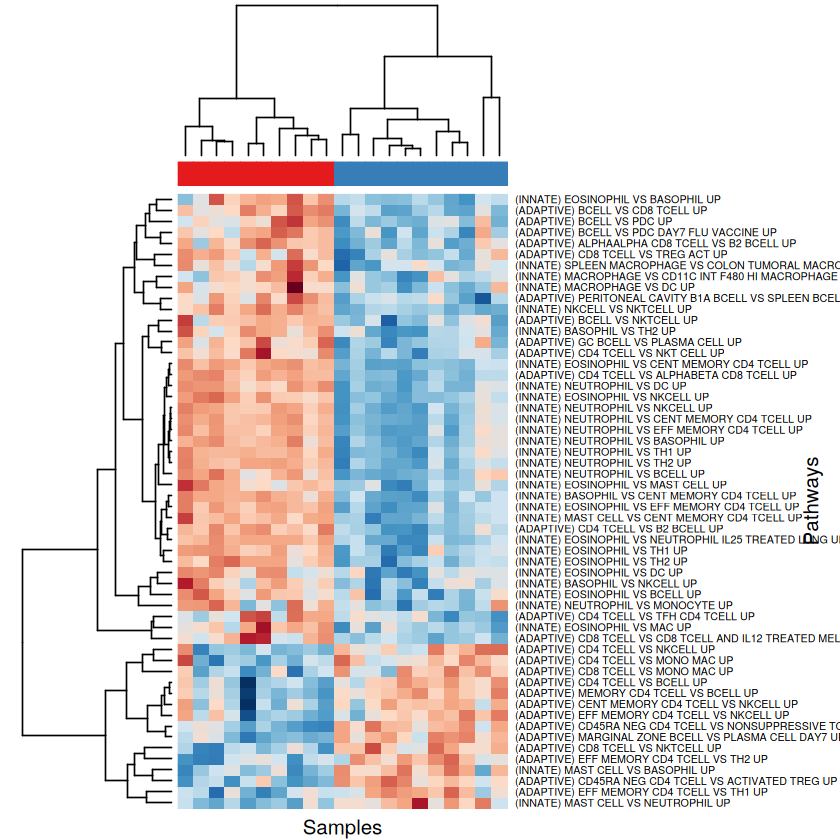

In [52]:
library(limma)
library(RColorBrewer)

## get DE pathway GSVA enrichment scores, removing the covariates effect
DEpwys_es <- removeBatchEffect(
  assay(es[DEpwys, ]),
  covariates = mod[, 2:ncol(mod), drop = FALSE],
  design = mod[, 1:2, drop = FALSE]
)

## create FIR color map
table(es$FIR)

fir_levels <- unique(es$FIR)

fircolor <- setNames(
  brewer.pal(max(3, length(fir_levels)), "Set1")[seq_along(fir_levels)],
  fir_levels
)

## cluster samples
sam_col_map <- fircolor[as.character(es$FIR)]
names(sam_col_map) <- colnames(DEpwys_es)

sampleClust <- hclust(
  as.dist(1 - cor(DEpwys_es, method = "spearman")),
  method = "complete"
)

## cluster pathways
gsetClust <- hclust(
  as.dist(1 - cor(t(DEpwys_es), method = "pearson")),
  method = "complete"
)

## annotate pathways as innate or adaptive
labrow <- rownames(DEpwys_es)

mask <- rownames(DEpwys_es) %in% innategsets
labrow[mask] <- paste("(INNATE)", labrow[mask], sep = "_")

mask <- rownames(DEpwys_es) %in% adaptivegsets
labrow[mask] <- paste("(ADAPTIVE)", labrow[mask], sep = "_")

labrow <- gsub("_", " ", gsub("GSE[0-9]+_", "", labrow))

## pathway expression color scale from blue low to red high
pwyexpcol <- colorRampPalette(brewer.pal(10, "RdBu"))(256)
pwyexpcol <- rev(pwyexpcol)

## generate heatmap
heatmap(
  DEpwys_es,
  ColSideColors = sam_col_map,
  xlab = "Samples",
  ylab = "Pathways",
  margins = c(2, 20),
  labCol = "",
  labRow = labrow,
  col = pwyexpcol,
  scale = "row",
  Colv = as.dendrogram(sampleClust),
  Rowv = as.dendrogram(gsetClust)
)

In [53]:
# res <- igsva()

In [54]:
# using proteomics data :
# https://www.bioconductor.org/packages/release/bioc/vignettes/GSVA/inst/doc/GSVA_proteomics.html